# Data Exploration

This notebook explores the cleaned datasets in `Data/processed`.

Goals:
- Check schema, sample records, and data quality.
- Understand sentiment and aspect distributions.
- Explore business/platform patterns.
- Inspect review text length behavior.

In [3]:
from pathlib import Path
import ast
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 120)

base = Path('..') if Path.cwd().name.lower() == 'notebook' else Path('.')
data_dir = base / 'Data' / 'processed'

train_wide = pd.read_csv(data_dir / 'train_cleaned_wide.csv')
train_long = pd.read_csv(data_dir / 'train_cleaned_long.csv')
val_wide = pd.read_csv(data_dir / 'validation_cleaned_wide.csv')
val_long = pd.read_csv(data_dir / 'validation_cleaned_long.csv')
unlabeled = pd.read_csv(data_dir / 'unlabeled_cleaned.csv')

print('Loaded files from:', data_dir.resolve())
print('train_wide:', train_wide.shape)
print('train_long:', train_long.shape)
print('val_wide:', val_wide.shape)
print('val_long:', val_long.shape)
print('unlabeled:', unlabeled.shape)

Loaded files from: C:\DeepX Hackathon\Data\processed
train_wide: (1971, 10)
train_long: (3333, 10)
val_wide: (500, 10)
val_long: (840, 10)
unlabeled: (7047, 8)


In [4]:
datasets = {
    'train_wide': train_wide,
    'train_long': train_long,
    'val_wide': val_wide,
    'val_long': val_long,
    'unlabeled': unlabeled,
}

for name, df in datasets.items():
    print(f'\n{name}')
    print('-' * len(name))
    print('Columns:', list(df.columns))
    print('Head:')
    display(df.head(3))


train_wide
----------
Columns: ['review_id', 'review_text', 'cleaned_review_text', 'star_rating', 'date', 'business_name', 'business_category', 'platform', 'aspects', 'aspect_sentiments']
Head:


,review_id,review_text,cleaned_review_text,star_rating,date,business_name,business_category,platform,aspects,aspect_sentiments
0,7238,?? ???? ????? ???????? ??? ????????,?? ?? ?? ?? ?? ??,3,2026-03-08 00:00:00,Noon,ecommerce,play_store,"[""app_experience"", ""delivery""]","{""app_experience"": ""negative"", ""delivery"": ""negative""}"
1,1036,?????? ???? ????? ?????? ???? ??????? ??? ??????? ????? ???? ???? ???? ?? ???? ?????? ????????,?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ??,5,??? ????? (2),???? ??? Mawlana Cafe,?????,google_maps,"[""cleanliness"", ""ambiance"", ""service""]","{""cleanliness"": ""positive"", ""ambiance"": ""positive"", ""service"": ""positive""}"
2,1975,????? ???? ?????? ????? ????? ??? ?? ??? ?????? ?? ???? ??? ???? ???\n????? ???? ???? ???? ???? ????? ???,?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ??,1,??? ???,??? ??? Beet Lahm,????,google_maps,"[""service"", ""delivery"", ""food""]","{""service"": ""negative"", ""delivery"": ""negative"", ""food"": ""neutral""}"



train_long
----------
Columns: ['review_id', 'review_text', 'cleaned_review_text', 'star_rating', 'date', 'business_name', 'business_category', 'platform', 'aspect', 'sentiment']
Head:


,review_id,review_text,cleaned_review_text,star_rating,date,business_name,business_category,platform,aspect,sentiment
0,7238,?? ???? ????? ???????? ??? ????????,?? ?? ?? ?? ?? ??,3,2026-03-08 00:00:00,Noon,ecommerce,play_store,app_experience,negative
1,7238,?? ???? ????? ???????? ??? ????????,?? ?? ?? ?? ?? ??,3,2026-03-08 00:00:00,Noon,ecommerce,play_store,delivery,negative
2,1036,?????? ???? ????? ?????? ???? ??????? ??? ??????? ????? ???? ???? ???? ?? ???? ?????? ????????,?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ??,5,??? ????? (2),???? ??? Mawlana Cafe,?????,google_maps,cleanliness,positive



val_wide
--------
Columns: ['review_id', 'review_text', 'cleaned_review_text', 'star_rating', 'date', 'business_name', 'business_category', 'platform', 'aspects', 'aspect_sentiments']
Head:


,review_id,review_text,cleaned_review_text,star_rating,date,business_name,business_category,platform,aspects,aspect_sentiments
0,4446,???? ????? ????????? ?????? ????? ??????????,?? ?? ?? ?? ?? ??,5,??? ?????,Sand salon,????? ?????,google_maps,"[""service""]","{""service"": ""positive""}"
1,8612,??????? ???? .. ????? ????? ????? ?? ???? ??????? ????? ???? ?????? ????? ???????? ??? ???? ?????? .. ?????,?? ?? .. ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? .. ??,4,2020-10-28 00:00:00,Aqarmap,real_estate,play_store,"[""app_experience""]","{""app_experience"": ""neutral""}"
2,6729,?????? ????? ???? ??????? ??????? ????? ???? ??? ???? ?????? ?? ???? ???? ?? 10 ???? ?????? ???? ???? ???? ?????? ???,?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? 10 ?? ?? ?? ?? ?? ?? ??,1,2026-02-04 00:00:00,Careem,transport,play_store,"[""service"", ""delivery"", ""price""]","{""service"": ""negative"", ""delivery"": ""negative"", ""price"": ""negative""}"



val_long
--------
Columns: ['review_id', 'review_text', 'cleaned_review_text', 'star_rating', 'date', 'business_name', 'business_category', 'platform', 'aspect', 'sentiment']
Head:


,review_id,review_text,cleaned_review_text,star_rating,date,business_name,business_category,platform,aspect,sentiment
0,4446,???? ????? ????????? ?????? ????? ??????????,?? ?? ?? ?? ?? ??,5,??? ?????,Sand salon,????? ?????,google_maps,service,positive
1,8612,??????? ???? .. ????? ????? ????? ?? ???? ??????? ????? ???? ?????? ????? ???????? ??? ???? ?????? .. ?????,?? ?? .. ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? .. ??,4,2020-10-28 00:00:00,Aqarmap,real_estate,play_store,app_experience,neutral
2,6729,?????? ????? ???? ??????? ??????? ????? ???? ??? ???? ?????? ?? ???? ???? ?? 10 ???? ?????? ???? ???? ???? ?????? ???,?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? 10 ?? ?? ?? ?? ?? ?? ??,1,2026-02-04 00:00:00,Careem,transport,play_store,service,negative



unlabeled
---------
Columns: ['review_id', 'review_text', 'cleaned_review_text', 'star_rating', 'date', 'business_name', 'business_category', 'platform']
Head:


,review_id,review_text,cleaned_review_text,star_rating,date,business_name,business_category,platform
0,1,Incroyablement grand avec des belles boutiques et 8 étages complet. J'ai passé la journée là bas tout est propre mêm...,Incroyablement grand avec des belles boutiques et 8 étages complet. J'ai passé la journée là bas tout est propre mêm...,5,??? 7 ?????,??? ???? ?????.,???? ????,google_maps
1,2,???? ???,?? ??,5,??? 12 ????,??? ???? ?????.,???? ????,google_maps
2,3,??? ??? ???? ????? ????? ???? ??????? ???????? ????? ??? ?? ???? ????? ????,?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ?? ??,5,??? ??? ????,??? ???? ?????.,???? ????,google_maps


In [5]:
quality_rows = []

for name, df in datasets.items():
    quality_rows.append(
        {
            'dataset': name,
            'rows': len(df),
            'cols': df.shape[1],
            'missing_cells': int(df.isna().sum().sum()),
            'duplicate_rows': int(df.duplicated().sum()),
            'empty_cleaned_text': int((df.get('cleaned_review_text', pd.Series(dtype=str)).fillna('').str.strip() == '').sum()) if 'cleaned_review_text' in df.columns else np.nan,
        }
    )

quality_report = pd.DataFrame(quality_rows)
quality_report

,dataset,rows,cols,missing_cells,duplicate_rows,empty_cleaned_text
0,train_wide,1971,10,0,0,0
1,train_long,3333,10,0,0,0
2,val_wide,500,10,0,0,0
3,val_long,840,10,0,0,0
4,unlabeled,7047,8,0,0,0


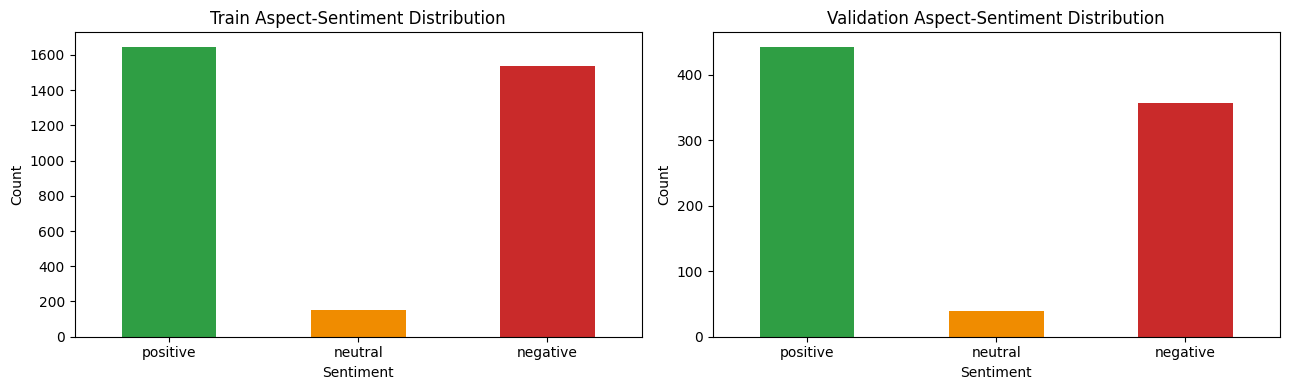

Train proportions:


,ratio
sentiment,
positive,0.493849
neutral,0.044704
negative,0.461446


Validation proportions:


,ratio
sentiment,
positive,0.527381
neutral,0.047619
negative,0.425000


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sent_train = train_long['sentiment'].value_counts().reindex(['positive', 'neutral', 'negative'], fill_value=0)
sent_val = val_long['sentiment'].value_counts().reindex(['positive', 'neutral', 'negative'], fill_value=0)

sent_train.plot(kind='bar', ax=axes[0], color=['#2f9e44', '#f08c00', '#c92a2a'])
axes[0].set_title('Train Aspect-Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

sent_val.plot(kind='bar', ax=axes[1], color=['#2f9e44', '#f08c00', '#c92a2a'])
axes[1].set_title('Validation Aspect-Sentiment Distribution')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('Train proportions:')
display((sent_train / sent_train.sum()).rename('ratio').to_frame())
print('Validation proportions:')
display((sent_val / sent_val.sum()).rename('ratio').to_frame())

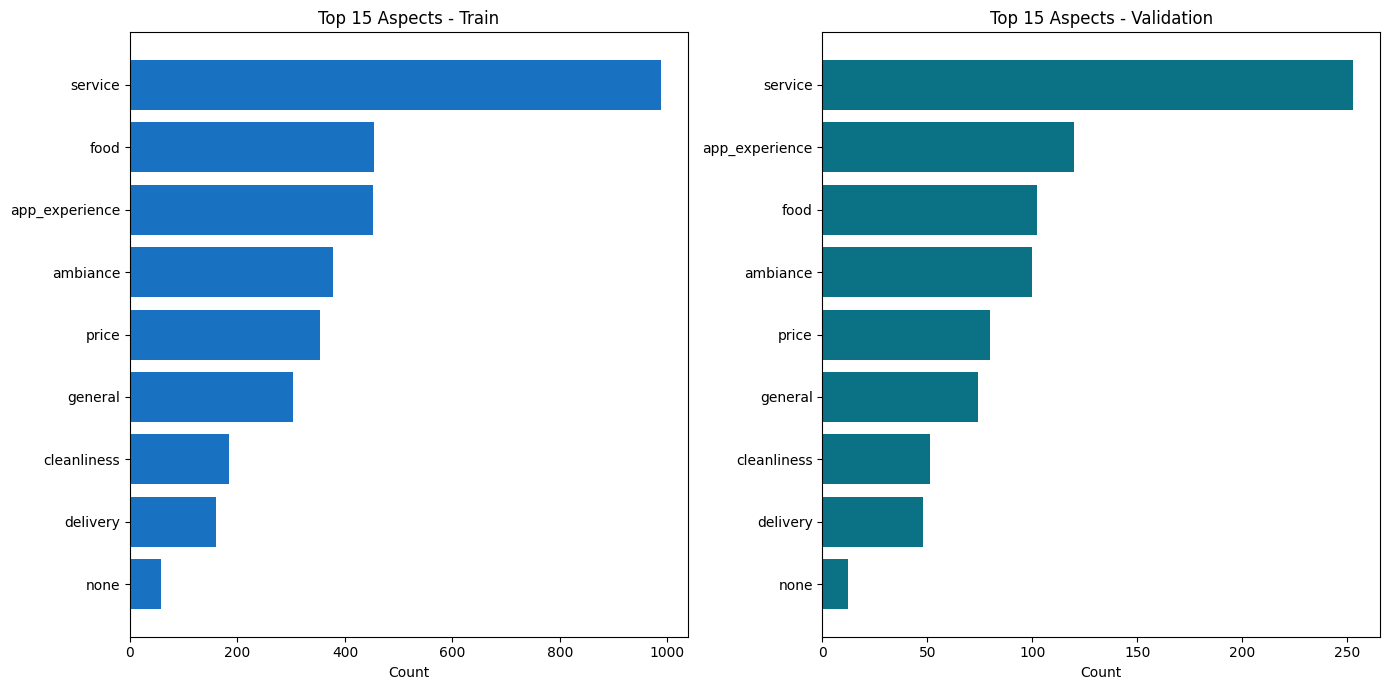

,train_count,val_count
aspect,,
ambiance,378,100
app_experience,453,120
cleanliness,185,51
delivery,161,48
food,454,102
general,303,74
none,57,12
price,354,80
service,988,253


In [7]:
top_train_aspects = train_long['aspect'].value_counts().head(15)
top_val_aspects = val_long['aspect'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh(top_train_aspects.index[::-1], top_train_aspects.values[::-1], color='#1971c2')
axes[0].set_title('Top 15 Aspects - Train')
axes[0].set_xlabel('Count')

axes[1].barh(top_val_aspects.index[::-1], top_val_aspects.values[::-1], color='#0b7285')
axes[1].set_title('Top 15 Aspects - Validation')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

display(pd.DataFrame({'train_count': top_train_aspects, 'val_count': top_val_aspects}).fillna(0).astype(int).head(20))

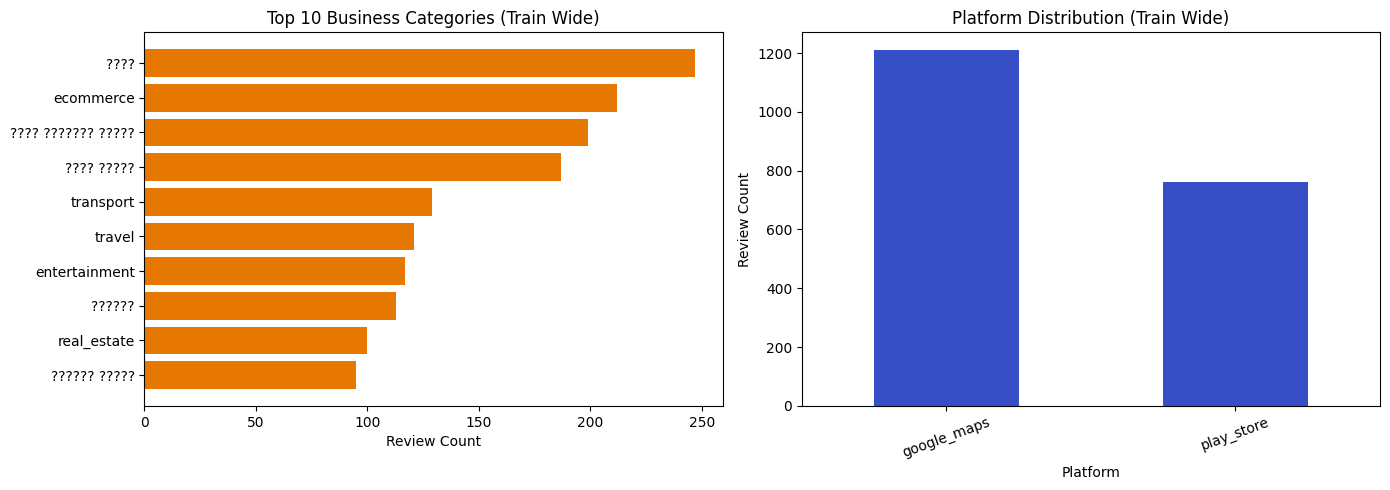

Top business categories:


,count
business_category,
????,247
ecommerce,212
???? ??????? ?????,199
???? ?????,187
transport,129
travel,121
entertainment,117
??????,113
real_estate,100


Platform counts:


,count
platform,
google_maps,1210
play_store,761


In [8]:
cat_counts = train_wide['business_category'].fillna('Unknown').value_counts().head(10)
platform_counts = train_wide['platform'].fillna('Unknown').value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1], color='#e67700')
axes[0].set_title('Top 10 Business Categories (Train Wide)')
axes[0].set_xlabel('Review Count')

platform_counts.plot(kind='bar', ax=axes[1], color='#364fc7')
axes[1].set_title('Platform Distribution (Train Wide)')
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('Review Count')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print('Top business categories:')
display(cat_counts.to_frame('count'))
print('Platform counts:')
display(platform_counts.to_frame('count'))

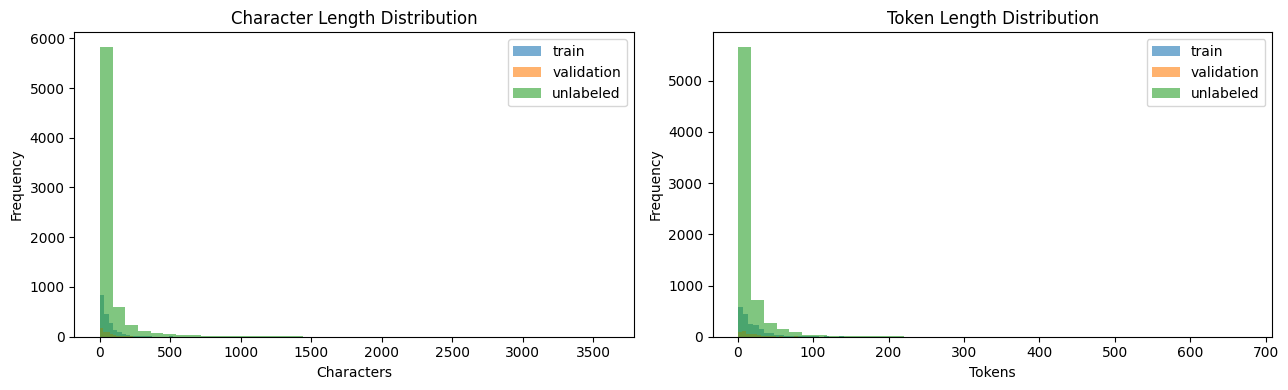

,dataset,avg_char_len,median_char_len,avg_token_len,median_token_len
0,train_wide,66.56,41.0,22.04,14.0
1,val_wide,61.02,41.0,20.04,14.0
2,unlabeled,66.54,19.0,14.16,6.0


In [9]:
def add_length_stats(df, text_col='cleaned_review_text'):
    out = df.copy()
    text_series = out[text_col].fillna('').astype(str)
    out['char_len'] = text_series.str.len()
    out['token_len'] = text_series.str.split().str.len()
    return out

train_wide_len = add_length_stats(train_wide)
val_wide_len = add_length_stats(val_wide)
unlabeled_len = add_length_stats(unlabeled)

length_report = pd.DataFrame({
    'dataset': ['train_wide', 'val_wide', 'unlabeled'],
    'avg_char_len': [train_wide_len['char_len'].mean(), val_wide_len['char_len'].mean(), unlabeled_len['char_len'].mean()],
    'median_char_len': [train_wide_len['char_len'].median(), val_wide_len['char_len'].median(), unlabeled_len['char_len'].median()],
    'avg_token_len': [train_wide_len['token_len'].mean(), val_wide_len['token_len'].mean(), unlabeled_len['token_len'].mean()],
    'median_token_len': [train_wide_len['token_len'].median(), val_wide_len['token_len'].median(), unlabeled_len['token_len'].median()],
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(train_wide_len['char_len'], bins=40, alpha=0.6, label='train')
axes[0].hist(val_wide_len['char_len'], bins=40, alpha=0.6, label='validation')
axes[0].hist(unlabeled_len['char_len'], bins=40, alpha=0.6, label='unlabeled')
axes[0].set_title('Character Length Distribution')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(train_wide_len['token_len'], bins=40, alpha=0.6, label='train')
axes[1].hist(val_wide_len['token_len'], bins=40, alpha=0.6, label='validation')
axes[1].hist(unlabeled_len['token_len'], bins=40, alpha=0.6, label='unlabeled')
axes[1].set_title('Token Length Distribution')
axes[1].set_xlabel('Tokens')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

length_report.round(2)

In [10]:
summary_points = []

summary_points.append(f"Train wide rows: {len(train_wide):,}; validation wide rows: {len(val_wide):,}; unlabeled rows: {len(unlabeled):,}")
summary_points.append(f"Train long sentiment mix (pos/neu/neg): {int(sent_train.get('positive',0)):,} / {int(sent_train.get('neutral',0)):,} / {int(sent_train.get('negative',0)):,}")
summary_points.append(f"Validation long sentiment mix (pos/neu/neg): {int(sent_val.get('positive',0)):,} / {int(sent_val.get('neutral',0)):,} / {int(sent_val.get('negative',0)):,}")
summary_points.append(f"Most common train aspect: {top_train_aspects.index[0]} ({int(top_train_aspects.iloc[0]):,})")
summary_points.append(f"Most common business category: {cat_counts.index[0]} ({int(cat_counts.iloc[0]):,})")
summary_points.append(
    f"Average cleaned review length (chars) train/val/unlabeled: "
    f"{train_wide_len['char_len'].mean():.1f} / {val_wide_len['char_len'].mean():.1f} / {unlabeled_len['char_len'].mean():.1f}"
)

print('Key EDA insights:')
for i, point in enumerate(summary_points, start=1):
    print(f"{i}. {point}")

Key EDA insights:
1. Train wide rows: 1,971; validation wide rows: 500; unlabeled rows: 7,047
2. Train long sentiment mix (pos/neu/neg): 1,646 / 149 / 1,538
3. Validation long sentiment mix (pos/neu/neg): 443 / 40 / 357
4. Most common train aspect: service (988)
5. Most common business category: ???? (247)
6. Average cleaned review length (chars) train/val/unlabeled: 66.6 / 61.0 / 66.5


In [13]:
train_wide.isnull().sum()
train_wide.info()

<class 'pandas.DataFrame'>
RangeIndex: 1971 entries, 0 to 1970
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   review_id            1971 non-null   int64
 1   review_text          1971 non-null   str  
 2   cleaned_review_text  1971 non-null   str  
 3   star_rating          1971 non-null   int64
 4   date                 1971 non-null   str  
 5   business_name        1971 non-null   str  
 6   business_category    1971 non-null   str  
 7   platform             1971 non-null   str  
 8   aspects              1971 non-null   str  
 9   aspect_sentiments    1971 non-null   str  
dtypes: int64(2), str(8)
memory usage: 154.1 KB
